# 01 — Kiểm ba dự đoán của RQ1 trên ETTh1, H = 96

Notebook này kiểm bảng trùng/tách 2×2 ở Mục 1.4 của kế hoạch:

| | λ = 0 | λ > 0 |
|---|---|---|
| **DLinear so với Linear** | trùng (dự đoán 1.1) | tách, qua metric `N`, phụ thuộc kernel (dự đoán 1.2) |
| **NLinear so với Linear** | tách, qua ràng buộc tổng hàng (dự đoán 1.3) | tách |

**Cách kiểm "tại nghiệm tối ưu" mà không cần huấn luyện SGD.** Với DLinear và NLinear, dự báo là hàm tuyến tính của tham số, nên tổng bình phương lỗi (có hoặc không có weight decay) là hàm bậc hai **lồi** theo tham số. Với hàm lồi khả vi, gradient bằng 0 tương đương cực tiểu toàn cục. Mỗi phép kiểm vì vậy gồm ba bước:

1. Giải nghiệm dạng đóng **trong chính tham số hoá của mô hình**: DLinear giải trên cặp `(W_t, W_s)` với đặc trưng do module tự tách ra; NLinear giải trên `W` với chuỗi đã trừ giá trị cuối. Bước này không dùng dẫn xuất ở Mục 1.
2. Nạp nghiệm vào **module của repo LTSF-Linear**, tính gradient bằng autograd. Gradient ≈ 0 so với gradient lúc khởi tạo là chứng nhận tối ưu toàn cục.
3. Trích ánh xạ tuyến tính thật của module bằng vector đơn vị, `W_eff[:, i] = f(e_i) − f(0)` và `b = f(0)`, rồi so với Linear và với công thức ở Mục 1.

Cách này chặt hơn huấn luyện SGD tới hội tụ: SGD dừng ở một sai số tối ưu hữu hạn, trộn sai số tối ưu vào câu hỏi cấu trúc. Khoảng cách của SGD so với nghiệm tối ưu là câu hỏi riêng của RQ3.

**Chuẩn bị:** `../data/ETTh1.csv` và repo LTSF-Linear clone vào `third_party/` (chạy ở gốc repo: `git clone https://github.com/cure-lab/LTSF-Linear third_party/LTSF-Linear`) (sửa `REPO_DIR` nếu để chỗ khác). Mọi phép tính chạy float64. Toàn bộ notebook mất khoảng 1,5 phút trên CPU một lõi.

In [1]:
import os, sys, time, types, importlib.util
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
DATA_PATH = "../data/ETTh1.csv"
REPO_DIR = "../third_party/LTSF-Linear"
OUT_DIR = "../results"
os.makedirs(OUT_DIR, exist_ok=True)

L, H = 336, 96
KERNELS = [5, 15, 25, 49]

def load_repo_model(name):
    """Nạp models/<name>.py của repo theo đường dẫn, tránh trùng tên với gói 'models' khác."""
    path = os.path.join(REPO_DIR, "models", f"{name}.py")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Không thấy {path}. Chạy ở gốc repo: git clone https://github.com/cure-lab/LTSF-Linear third_party/LTSF-Linear")
    spec = importlib.util.spec_from_file_location(f"ltsf_{name}", path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

DL = load_repo_model("DLinear")
NL = load_repo_model("NLinear")
cfg = types.SimpleNamespace(seq_len=L, pred_len=H, enc_in=1, individual=False)   # nhánh dùng chung trọng số
print("Đã nạp DLinear và NLinear từ", os.path.abspath(REPO_DIR))

Đã nạp DLinear và NLinear từ C:\Users\Admin\Documents\dlinear\third_party\LTSF-Linear


## 1. Dữ liệu và solver

Dùng các hàm đã kiểm trong `src/` (`src/data.py`, `src/solvers.py`, `src/metrics.py`; `tests/` kiểm lại đúng số của `Nlinear.ipynb`).

In [2]:
from src.data import load_etth1, make_dataset
from src.metrics import mse
from src.solvers import fit_with_bias, nlinear_constrained, ols, ridge, ridge_path
from src.operators import build_N, build_P, nlinear_effective

In [3]:
train, val, test = load_etth1(DATA_PATH, L)
X_tr, Y_tr = make_dataset(train, L, H)
X_va, Y_va = make_dataset(val, L, H)
X_te, Y_te = make_dataset(test, L, H)
n = X_tr.shape[0]
print("train", X_tr.shape, "val", X_va.shape, "test", X_te.shape)

x_bar, y_bar = X_tr.mean(0), Y_tr.mean(0)
Xc = X_tr - x_bar
A, C = Xc.T @ Xc, Xc.T @ (Y_tr - y_bar)          # A = X_cᵀX_c, C = X_cᵀY_c (đã trừ trung bình)
W_lin, b_lin = fit_with_bias(ols, X_tr, Y_tr)
pred_lin_te = X_te @ W_lin.T + b_lin
ev_A = np.linalg.eigvalsh(A)
print(f"Linear OLS: MSE test = {mse(W_lin, b_lin, X_te, Y_te):.8f}  (kỳ vọng 0.3702 như Nlinear.ipynb)")
print(f"Số điều kiện của A: {ev_A.max() / ev_A.min():.0f}")

train (57463, 336) val (19495, 336) test (19495, 336)


Linear OLS: MSE test = 0.37023527  (kỳ vọng 0.3702 như Nlinear.ipynb)
Số điều kiện của A: 7446


## 2. Toán tử `P` và `N`

`P` là trung bình trượt của LTSF-Linear: đệm `(k−1)/2` bản sao giá trị đầu và cuối, rồi `AvgPool1d` bước 1. `N = PᵀP + (I−P)ᵀ(I−P)`.

Ba điều phải thấy:

- Cột `i` của `P` trùng `moving_avg(e_i)` của repo tới sai số máy, ở cả bốn kernel.
- Mỗi hàng của `P` cộng bằng 1.
- `λ_min(N) ≥ 1/2`. Đây là cận chặt hơn `N ≻ 0` ở kế hoạch: `vᵀNv = ‖Pv‖² + ‖(I−P)v‖² ≥ ½‖Pv + (I−P)v‖² = ½‖v‖²`. Hệ quả: `N⁻¹ ⪯ 2I`, tức weight decay của DLinear không bao giờ phạt nặng hơn gấp đôi ridge đẳng hướng theo bất kỳ hướng nào.

Đối chứng âm: dựng `P` sai bằng đệm 0 thay vì đệm lặp. Phép kiểm phải bắt được sai lệch này.

In [4]:
E_in = torch.eye(L).unsqueeze(-1)                 # [L (batch), L (thời gian), 1]: mẫu i là e_i
rows = []
for k in KERNELS:
    P = build_P(L, k)
    with torch.no_grad():
        cols = DL.moving_avg(k, stride=1)(E_in).squeeze(-1).numpy()   # hàng i = moving_avg(e_i) = cột i của P
    ev = np.linalg.eigvalsh(build_N(P))
    rows.append(dict(k=k, max_err_P=np.abs(cols.T - P).max(), max_err_rowsum=np.abs(P.sum(1) - 1).max(),
                     eig_N_min=ev.min(), eig_N_max=ev.max()))
print(pd.DataFrame(rows).to_string(index=False, formatters={
    "max_err_P": "{:.1e}".format, "max_err_rowsum": "{:.1e}".format,
    "eig_N_min": "{:.4f}".format, "eig_N_max": "{:.4f}".format}))

P_zero = np.zeros((L, L))                          # đối chứng âm: đệm 0
for t in range(L):
    for m in range(25):
        if 0 <= t + m - 12 < L:
            P_zero[t, t + m - 12] += 1 / 25
with torch.no_grad():
    cols = DL.moving_avg(25, stride=1)(E_in).squeeze(-1).numpy()
print(f"\nĐối chứng âm (đệm 0, k = 25): max|P_sai − moving_avg| = {np.abs(cols.T - P_zero).max():.2f}")

 k max_err_P max_err_rowsum eig_N_min eig_N_max
 5   1.1e-16        0.0e+00    0.5000    1.6248
15   5.6e-17        0.0e+00    0.5003    1.9999
25   1.1e-16        1.1e-16    0.5006    2.8076
49   2.2e-16        2.2e-16    0.5009    4.7941

Đối chứng âm (đệm 0, k = 25): max|P_sai − moving_avg| = 0.48


## 3. Công cụ kiểm qua module

- `probe_linear_map`: đọc ánh xạ tuyến tính mà module **thật sự** tính, chỉ dùng `forward`. Không cần biết `P`.
- `grad_norm`: chuẩn gradient của tổng bình phương lỗi trên toàn bộ train (cộng `λ·Σ‖W‖²` nếu có), tính bằng autograd qua module.
- `rms_gap`: căn trung bình bình phương chênh lệch dự báo của hai mô hình trên test, cùng đơn vị với RMSE. Mọi mô hình ở đây đều có `b = ȳ − W x̄`, nên chênh lệch dự báo chỉ phụ thuộc `ΔW` qua ma trận Gram của test.

In [5]:
Xt_tr = torch.from_numpy(X_tr).unsqueeze(-1)       # [n, L, 1]: mỗi kênh là một mẫu, đúng như dùng chung trọng số
Yt_tr = torch.from_numpy(Y_tr).unsqueeze(-1)
Xt_te = torch.from_numpy(X_te).unsqueeze(-1)

def probe_linear_map(model):
    with torch.no_grad():
        out = model(torch.cat([torch.zeros(1, L, 1), E_in], 0)).squeeze(-1).numpy()   # [L+1, H]
    return (out[1:] - out[0]).T, out[0]

def grad_norm(model, lam=0.0, penalized=()):
    model.zero_grad()
    loss = ((model(Xt_tr) - Yt_tr) ** 2).sum()
    if lam:
        loss = loss + lam * sum((w ** 2).sum() for w in penalized)
    loss.backward()
    return float(torch.sqrt(sum((p.grad ** 2).sum() for p in model.parameters())))

def predict_module(model, Xt):
    with torch.no_grad():
        return model(Xt).squeeze(-1).numpy()

def make_dlinear(k, seed=0):
    torch.manual_seed(seed)
    m = DL.Model(cfg).double()
    m.decompsition = DL.series_decomp(k)           # repo cố định k = 25 trong __init__; thay khối tách để quét k
    return m

def set_dlinear(m, W_t, W_s, b):
    with torch.no_grad():
        m.Linear_Trend.weight.copy_(torch.from_numpy(W_t)); m.Linear_Trend.bias.copy_(torch.from_numpy(b))
        m.Linear_Seasonal.weight.copy_(torch.from_numpy(W_s)); m.Linear_Seasonal.bias.zero_()

S_te = (X_te - x_bar).T @ (X_te - x_bar) / (X_te.shape[0] * H)
def rms_gap(W1, W2):
    D = W1 - W2
    return float(np.sqrt(max(np.sum((D @ S_te) * D), 0.0)))

## 4. Dự đoán 1.1 — λ = 0: DLinear ≡ Linear

Với mỗi kernel, lấy đặc trưng `Z = [trend, seasonal]` (672 cột) do chính `series_decomp` của repo tạo ra, giải bình phương tối thiểu chuẩn nhỏ nhất bằng `lstsq`, nạp `(W_t, W_s, b)` vào module.

Cần thấy:

- `rank(Z) = 336`, không phải 672. Đây là gốc đại số của 1.1: hai nhánh xu hướng và mùa vụ cộng lại đúng bằng `x`, nên 672 đặc trưng chỉ trải một không gian 336 chiều. Cột `sv_next` là giá trị kỳ dị đầu tiên bị cắt, phải nhỏ hơn giá trị giữ lại cuối cùng nhiều bậc.
- `W_eff` đọc từ module trùng `W_t P + W_s (I−P)` (kiểm lại `P` trong bối cảnh đã fit) và trùng `W_lin`.
- Dự báo trên test và MSE test trùng Linear, **như nhau ở mọi kernel**.
- Gradient qua module tại nghiệm nhỏ hơn gradient lúc khởi tạo nhiều bậc.

In [6]:
gram_cache, W_eff_dl0, rows = {}, {}, []
Yc_tr = Y_tr - y_bar
t0 = time.time()
for k in KERNELS:
    m = make_dlinear(k)
    g_init = grad_norm(m)
    with torch.no_grad():
        seas, trend = m.decompsition(Xt_tr)
    Z = torch.cat([trend, seas], dim=1).squeeze(-1).numpy().copy()   # [n, 2L]: L cột trend rồi L cột seasonal
    del seas, trend
    z_bar = Z.mean(0)
    Z -= z_bar
    G, _, rank, sv = np.linalg.lstsq(Z, Yc_tr, rcond=1e-10)
    gram_cache[k] = (Z.T @ Z, Z.T @ Yc_tr, z_bar)          # dùng lại ở mục 5
    del Z
    G = G.T
    W_t, W_s, b = G[:, :L], G[:, L:], y_bar - G @ z_bar
    set_dlinear(m, W_t, W_s, b)
    W_eff, b_eff = probe_linear_map(m)
    W_eff_dl0[k] = W_eff
    P = build_P(L, k)
    pred_te = predict_module(m, Xt_te)
    rows.append(dict(
        k=k, rank_Z=rank, sv_last_kept=sv[rank - 1], sv_next=sv[rank],
        err_formula=np.abs(W_eff - (W_t @ P + W_s @ (np.eye(L) - P))).max(),
        rel_dW=np.linalg.norm(W_eff - W_lin) / np.linalg.norm(W_lin),
        max_dpred_test=np.abs(pred_te - pred_lin_te).max(),
        mse_test=np.mean((Y_te - pred_te) ** 2),
        grad_ratio=grad_norm(m) / g_init))
res_11 = pd.DataFrame(rows)
print(res_11.to_string(index=False, formatters={
    "sv_last_kept": "{:.1f}".format, "sv_next": "{:.1e}".format, "err_formula": "{:.1e}".format,
    "rel_dW": "{:.1e}".format, "max_dpred_test": "{:.1e}".format, "mse_test": "{:.10f}".format,
    "grad_ratio": "{:.1e}".format}))
print(f"Linear OLS mse_test = {np.mean((Y_te - pred_lin_te) ** 2):.10f}   ({time.time() - t0:.0f} s)")

 k  rank_Z sv_last_kept sv_next err_formula  rel_dW max_dpred_test     mse_test grad_ratio
 5     336         30.3 2.8e-12     1.1e-16 4.0e-13        2.2e-13 0.3702352707    1.5e-15
15     336         36.6 1.6e-11     1.1e-16 4.0e-13        2.1e-13 0.3702352707    5.7e-15
25     336         35.7 4.3e-12     1.1e-16 4.0e-13        2.1e-13 0.3702352707    2.2e-15
49     336         36.6 1.3e-11     2.2e-16 4.0e-13        2.1e-13 0.3702352707    6.2e-15
Linear OLS mse_test = 0.3702352707   (14 s)


**Đọc kết quả.** `rank(Z)` bằng đúng 336 với khoảng cách khoảng 12 bậc giữa `sv_last_kept` và `sv_next`. `W_eff` của module khớp `W_lin` ở mức ~1e-13 tương đối, dự báo test khớp ~1e-13, MSE test trùng tới 10 chữ số, và kết quả **không phụ thuộc k**. Kế hoạch ghi kỳ vọng ~1e-14; mức 1e-13 quan sát được vẫn là sai số máy float64 (số điều kiện của `A` khoảng 7.400, cộng thêm đường tính qua SVD). `grad_ratio` ~1e-15 là chứng nhận tối ưu toàn cục. **Dự đoán 1.1 đúng.**

## 5. Dự đoán 1.2 — λ > 0: DLinear ≠ Linear

Quy ước: hàm mục tiêu là `tổng bình phương lỗi + λ(‖W_t‖² + ‖W_s‖²)`, không phạt bias, cùng đơn vị với hàm `ridge` của bạn. Đổi sang PyTorch: loss là MSE trung bình trên `n·H` phần tử cộng `weight_decay` kiểu L2 thì `weight_decay ≈ 2λ/(n·H)`, với `n·H = 5.516.448`.

Ba cách tính được so với nhau ở λ ∈ {1, 10², 10⁴, 10⁶}:

- **direct**: ridge trực tiếp trên `(W_t, W_s)` với đặc trưng của module (672 cột), rồi `W_eff = W_t P + W_s(I−P)`
- **formula_N**: công thức của kế hoạch, `W_effᵀ = (A + λN⁻¹)⁻¹C`
- **iso**: ridge đẳng hướng của Linear, `(A + λI)⁻¹C`

Cần thấy: direct trùng formula_N tới sai số máy, còn khác iso. Thêm hai kiểm: đẳng thức phạt `‖W_t‖² + ‖W_s‖² = tr(W_eff N⁻¹ W_effᵀ)` tại nghiệm, và gradient qua module có weight decay tại λ = 10⁴.

In [7]:
I_L = np.eye(L)
Ninv = {k: np.linalg.inv(build_N(build_P(L, k))) for k in KERNELS}

def W_dlinear_wd(lam, k):
    return np.linalg.solve(A + lam * Ninv[k], C).T

rows = []
for k in KERNELS:
    ZZ, ZY, z_bar = gram_cache[k]
    P = build_P(L, k)
    for lam in [1e0, 1e2, 1e4, 1e6]:
        G = np.linalg.solve(ZZ + lam * np.eye(2 * L), ZY).T
        W_t, W_s = G[:, :L], G[:, L:]
        W_direct = W_t @ P + W_s @ (I_L - P)
        W_form = W_dlinear_wd(lam, k)
        W_iso = np.linalg.solve(A + lam * I_L, C).T
        row = dict(k=k, lam=lam,
                   direct_vs_formula_N=np.linalg.norm(W_direct - W_form) / np.linalg.norm(W_form),
                   direct_vs_iso=np.linalg.norm(W_direct - W_iso) / np.linalg.norm(W_iso),
                   penalty_ratio=((W_t ** 2).sum() + (W_s ** 2).sum()) / np.trace(W_form @ Ninv[k] @ W_form.T))
        if lam == 1e4:
            m = make_dlinear(k)
            g_init = grad_norm(m, lam, [m.Linear_Trend.weight, m.Linear_Seasonal.weight])
            set_dlinear(m, W_t, W_s, y_bar - G @ z_bar)
            row["grad_ratio"] = grad_norm(m, lam, [m.Linear_Trend.weight, m.Linear_Seasonal.weight]) / g_init
        rows.append(row)
res_12 = pd.DataFrame(rows)
print(res_12.to_string(index=False, na_rep="", formatters={
    "lam": "{:.0e}".format, "direct_vs_formula_N": "{:.1e}".format, "direct_vs_iso": "{:.1e}".format,
    "penalty_ratio": "{:.12f}".format, "grad_ratio": "{:.1e}".format}))

 k   lam direct_vs_formula_N direct_vs_iso  penalty_ratio grad_ratio
 5 1e+00             4.1e-13       8.5e-05 1.000000000000           
 5 1e+02             3.9e-13       8.0e-03 1.000000000000           
 5 1e+04             1.2e-13       1.2e-01 1.000000000000    5.7e-16
 5 1e+06             5.1e-15       1.1e-01 1.000000000000           
15 1e+00             4.0e-13       8.5e-05 1.000000000000           
15 1e+02             3.9e-13       8.2e-03 1.000000000000           
15 1e+04             1.0e-13       1.9e-01 1.000000000000    5.7e-16
15 1e+06             4.8e-15       2.5e-01 1.000000000000           
25 1e+00             4.1e-13       1.1e-04 1.000000000000           
25 1e+02             4.0e-13       1.0e-02 1.000000000000           
25 1e+04             9.8e-14       2.8e-01 1.000000000000    5.8e-16
25 1e+06             4.4e-15       2.8e-01 1.000000000000           
49 1e+00             4.2e-13       1.3e-04 1.000000000000           
49 1e+02             4.0e-13      

**Đọc kết quả.** `direct_vs_formula_N` ở mức 1e-13 đến 1e-15 với mọi k và λ, `penalty_ratio` bằng 1 tới 12 chữ số: công thức metric `N` đúng. `direct_vs_iso` đi từ ~1e-4 ở λ = 1 lên 0,1–0,5 ở λ = 10⁴–10⁶, và ở cùng λ thì nhìn chung lớn hơn khi k lớn. Gradient qua module có weight decay cũng ~1e-15 so với lúc khởi tạo. **Dự đoán 1.2 đúng.** Mục 7 quét λ dày hơn và kiểm xem mức tách có phải chỉ là đổi thang λ không.

## 6. Dự đoán 1.3 — NLinear ≠ Linear

**direct**: hồi quy `y − x_L·1_H` lên `x − x_L·1_L`, bỏ cột cuối vì cột đó luôn bằng 0 (trọng số của nó không ảnh hưởng dự báo, nên đặt 0). Rồi `W_eff = W(I − 1_L e_Lᵀ) + 1_H e_Lᵀ`.

**formula**: `fit_with_bias(nlinear_constrained, ...)`, tức công thức `V` của kế hoạch. Trước đây mới kiểm trên dữ liệu giả.

Kế hoạch viết mức tách "bằng đúng" `‖W_ols 1_L − 1_H‖`. Chính xác hơn, với `r = W_ols 1_L − 1_H`, `u = A⁻¹1_L`, `s = 1_Lᵀu`, có ba đẳng thức kiểm được:

- `V − W_ols = −(1/s)·r uᵀ` là ma trận hạng 1, nên `‖V − W_ols‖_F = ‖r‖·‖u‖/s`. Mức tách **tỉ lệ** với `‖r‖`, hệ số `‖u‖/s` chỉ phụ thuộc dữ liệu đầu vào.
- Theo từng hàng: `‖(V − W_ols)_h‖ = |r_h|·‖u‖/s`.
- Phần tăng tổng bình phương lỗi trên train: `SSE(V) − SSE(W_ols) = ‖r‖²/s`, vì phần dư OLS trực giao với không gian cột.

In [8]:
ones_L, ones_H = np.ones(L), np.ones(H)

def nlinear_direct(X, Y, lam=0.0):
    last = X[:, -1:]
    W, b = fit_with_bias(lambda X_, Y_: ridge(X_, Y_, lam), (X - last)[:, :-1], Y - last)
    W_full = np.concatenate([W, np.zeros((H, 1))], axis=1)            # trọng số nạp vào nn.Linear
    W_eff = W_full - np.outer(W_full @ ones_L - ones_H, I_L[-1])      # W(I − 1 e_Lᵀ) + 1_H e_Lᵀ
    return W_full, W_eff, b

W_full, W_nl, b_nl = nlinear_direct(X_tr, Y_tr)
V, b_V = fit_with_bias(nlinear_constrained, X_tr, Y_tr)

torch.manual_seed(0)
m = NL.Model(cfg).double()
g_init = grad_norm(m)
with torch.no_grad():
    m.Linear.weight.copy_(torch.from_numpy(W_full)); m.Linear.bias.copy_(torch.from_numpy(b_nl))
W_probe, b_probe = probe_linear_map(m)
pred_nl_te = predict_module(m, Xt_te)
with torch.no_grad():
    x5 = Xt_te[:5]
    shift = (m(x5 + 3.0) - m(x5)).numpy()
W_nl0 = W_probe

print(f"direct so với formula:     rel‖ΔW‖ = {np.linalg.norm(W_nl - V) / np.linalg.norm(V):.1e},  max|Δb| = {np.abs(b_nl - b_V).max():.1e}")
print(f"module so với formula:     rel‖ΔW‖ = {np.linalg.norm(W_probe - V) / np.linalg.norm(V):.1e},  max|Δŷ test| = {np.abs(pred_nl_te - (X_te @ V.T + b_V)).max():.1e}")
print(f"tổng hàng của module:      max|W_eff·1 − 1| = {np.abs(W_probe @ ones_L - 1).max():.1e}")
print(f"dịch đầu vào +3:           đầu ra dịch trong [{shift.min():.15f}, {shift.max():.15f}]")
print(f"gradient qua module:       ‖∇‖ tại nghiệm / ‖∇‖ lúc khởi tạo = {grad_norm(m) / g_init:.1e}")

direct so với formula:     rel‖ΔW‖ = 6.1e-13,  max|Δb| = 5.6e-16
module so với formula:     rel‖ΔW‖ = 6.1e-13,  max|Δŷ test| = 4.0e-13
tổng hàng của module:      max|W_eff·1 − 1| = 6.7e-16
dịch đầu vào +3:           đầu ra dịch trong [3.000000000000000, 3.000000000000000]
gradient qua module:       ‖∇‖ tại nghiệm / ‖∇‖ lúc khởi tạo = 7.3e-16


In [9]:
r = W_lin @ ones_L - ones_H
u = np.linalg.solve(A, ones_L)
s = ones_L @ u
dW = V - W_lin
sse = lambda W, b: np.sum((Y_tr - X_tr @ W.T - b) ** 2)
print(f"Tổng hàng của W_lin: h=1 {1 + r[0]:.4f}, h=96 {1 + r[-1]:.4f};  ‖r‖ = {np.linalg.norm(r):.6f};  ‖u‖/s = {np.linalg.norm(u) / s:.6f}")
print(f"‖V − W_lin‖_F = {np.linalg.norm(dW):.15f}")
print(f"‖r‖·‖u‖/s     = {np.linalg.norm(r) * np.linalg.norm(u) / s:.15f}")
print(f"Theo hàng: max | ‖ΔW_h‖ − |r_h|·‖u‖/s | = {np.abs(np.linalg.norm(dW, axis=1) - np.abs(r) * np.linalg.norm(u) / s).max():.1e}")
print(f"SSE_train(V) − SSE_train(W_lin) = {sse(V, b_V) - sse(W_lin, b_lin):.6f}")
print(f"‖r‖²/s                           = {r @ r / s:.6f}")
print()
mae = lambda W, b, X, Y: np.mean(np.abs(Y - X @ W.T - b))
tab = pd.DataFrame({
    "MSE train": [sse(W_lin, b_lin) / (n * H), sse(V, b_V) / (n * H)],
    "MSE val": [mse(W_lin, b_lin, X_va, Y_va), mse(V, b_V, X_va, Y_va)],
    "MSE test": [mse(W_lin, b_lin, X_te, Y_te), mse(V, b_V, X_te, Y_te)],
    "MAE test": [mae(W_lin, b_lin, X_te, Y_te), mae(V, b_V, X_te, Y_te)]}, index=["Linear (λ=0)", "NLinear (λ=0)"])
print(tab.to_string(float_format="{:.6f}".format))
print(f"\nRMS chênh lệch dự báo NLinear − Linear trên test: {rms_gap(V, W_lin):.4f}   (RMSE test của Linear: {np.sqrt(mse(W_lin, b_lin, X_te, Y_te)):.4f})")

Tổng hàng của W_lin: h=1 0.9925, h=96 0.8917;  ‖r‖ = 0.761935;  ‖u‖/s = 0.091085
‖V − W_lin‖_F = 0.069400611212911
‖r‖·‖u‖/s     = 0.069400611212911
Theo hàng: max | ‖ΔW_h‖ − |r_h|·‖u‖/s | = 1.8e-17


SSE_train(V) − SSE_train(W_lin) = 17002.829247
‖r‖²/s                           = 17002.829247



               MSE train  MSE val  MSE test  MAE test
Linear (λ=0)    0.329728 0.651630  0.370235  0.391538
NLinear (λ=0)   0.332810 0.670366  0.370199  0.391506

RMS chênh lệch dự báo NLinear − Linear trên test: 0.0514   (RMSE test của Linear: 0.6085)


**Đọc kết quả.** Nghiệm NLinear giải trực tiếp, công thức `V`, và ánh xạ đọc từ module khớp nhau tới ~1e-13; tổng hàng bằng 1 tới sai số máy; dịch đầu vào 3 thì đầu ra dịch đúng 3. Cả ba đẳng thức về mức tách khớp tới 15 chữ số. **Dự đoán 1.3 đúng ở λ = 0**, và nghiệm `nlinear_constrained` giờ đã kiểm trên ETTh1.

Tổng hàng của `W_lin` giảm từ 0,992 (h = 1) xuống 0,892 (h = 96): Linear kéo dự báo về trung bình train, kéo mạnh hơn ở horizon xa. NLinear cấm việc này. Hai mô hình cho dự báo khác nhau rõ (RMS chênh 0,051, khoảng 8% RMSE) nhưng MSE test gần như bằng nhau; trên validation, NLinear kém hơn (0,670 so với 0,652).

## 7. Quét λ: mức tách có thật, hay chỉ là đổi thang λ?

Nếu DLinear có weight decay ở λ chỉ là ridge đẳng hướng ở một λ' khác, thì khi chọn λ* trên validation, hai mô hình sẽ thu về nhau. Để kiểm, với mỗi mô hình ở mỗi λ, đo:

- `rms_gap_same`: RMS chênh lệch dự báo trên test so với Linear-ridge **cùng λ**
- `rms_gap_best`: như trên nhưng so với Linear-ridge ở **λ' khớp nhất**, tìm trên lưới 40 điểm mỗi bậc. Đây là phần tách không xoá được bằng cách chỉnh λ.

Tại λ = 0, DLinear dùng `W_eff` đọc từ module ở mục 4 và NLinear dùng nghiệm đọc từ module ở mục 6. Với λ > 0, DLinear dùng công thức metric `N` (đã kiểm ở mục 5 tới 1e-13), NLinear dùng nghiệm giải trực tiếp trên chuỗi đã trừ giá trị cuối (Gram tính một lần). Tất cả chỉ dùng train để fit.

In [10]:
W_ridge = ridge_path(Xc, Y_tr - y_bar)                # phân rã A = X_cᵀX_c một lần, mỗi λ một phép nhân

Xn = (X_tr - X_tr[:, -1:])[:, :-1]                   # NLinear: chuỗi đã trừ giá trị cuối, bỏ cột 0
Yn = Y_tr - X_tr[:, -1:]
xn_bar, yn_bar = Xn.mean(0), Yn.mean(0)
Xn -= xn_bar
An, Cn = Xn.T @ Xn, Xn.T @ (Yn - yn_bar)
del Xn, Yn
def W_nlinear_wd(lam):
    W = np.linalg.solve(An + lam * np.eye(L - 1), Cn).T
    return nlinear_effective(W)                                        # W_eff, tổng hàng = 1

LAM_MATCH = np.concatenate([[0.0], np.logspace(-1, 10, 441)])
WR_bank = np.stack([W_ridge(l) for l in LAM_MATCH])                  # [441, H, L]
WR_quad = np.einsum("ghl,ghl->g", WR_bank @ S_te, WR_bank)
def best_ridge_match(W):
    WS = W @ S_te
    quad = np.sum(WS * W) - 2 * np.einsum("hl,ghl->g", WS, WR_bank) + WR_quad
    j = int(np.argmin(quad))
    return rms_gap(W, WR_bank[j]), LAM_MATCH[j]

def pred(W, X):                                        # mọi mô hình: b = ȳ − W x̄
    return (X - x_bar) @ W.T + y_bar

def metrics(W):
    return dict(mse_val=np.mean((Y_va - pred(W, X_va)) ** 2),
                mse_test=np.mean((Y_te - pred(W, X_te)) ** 2),
                mae_test=np.mean(np.abs(Y_te - pred(W, X_te))),
                rowsum_mean=W.sum(1).mean())

In [11]:
LAMS = np.concatenate([[0.0], np.logspace(0, 8, 33)])
rows = []
t0 = time.time()
for lam in LAMS:
    WR = W_ridge(lam)
    rows.append(dict(model="Linear", k=np.nan, lam=lam, rel_dW=0.0, rms_gap_same=0.0, rms_gap_best=0.0,
                     lam_best=lam, **metrics(WR)))
    cands = [("DLinear", k, W_eff_dl0[k] if lam == 0 else W_dlinear_wd(lam, k)) for k in KERNELS]
    cands.append(("NLinear", np.nan, W_nl0 if lam == 0 else W_nlinear_wd(lam)))
    for name, k, W in cands:
        gap_best, lam_best = best_ridge_match(W)
        rows.append(dict(model=name, k=k, lam=lam, rel_dW=np.linalg.norm(W - WR) / np.linalg.norm(WR),
                         rms_gap_same=rms_gap(W, WR), rms_gap_best=gap_best, lam_best=lam_best, **metrics(W)))
sweep = pd.DataFrame(rows)
sweep.to_csv(os.path.join(OUT_DIR, "three_predictions_sweep.csv"), index=False)
print(f"{len(sweep)} dòng, lưu tại {OUT_DIR}/three_predictions_sweep.csv   ({time.time() - t0:.0f} s)")

show = sweep[sweep.lam.isin([0, 1e2, 1e4, 1e6, 1e8]) & (sweep.model != "Linear")]
print(show.to_string(index=False, na_rep="", formatters={
    "k": "{:.0f}".format, "lam": "{:.0e}".format, "rel_dW": "{:.2e}".format, "rms_gap_same": "{:.2e}".format,
    "rms_gap_best": "{:.2e}".format, "lam_best": "{:.3g}".format, "mse_val": "{:.4f}".format,
    "mse_test": "{:.4f}".format, "mae_test": "{:.4f}".format, "rowsum_mean": "{:.4f}".format}))

204 dòng, lưu tại ../results/three_predictions_sweep.csv   (33 s)
  model  k   lam   rel_dW rms_gap_same rms_gap_best lam_best mse_val mse_test mae_test rowsum_mean
DLinear  5 0e+00 5.06e-13     3.73e-14     3.73e-14        0  0.6516   0.3702   0.3915      0.9266
DLinear 15 0e+00 5.06e-13     3.74e-14     3.74e-14        0  0.6516   0.3702   0.3915      0.9266
DLinear 25 0e+00 5.05e-13     3.72e-14     3.72e-14        0  0.6516   0.3702   0.3915      0.9266
DLinear 49 0e+00 5.06e-13     3.75e-14     3.75e-14        0  0.6516   0.3702   0.3915      0.9266
NLinear    0e+00 1.99e-02     5.14e-02     5.14e-02        0  0.6704   0.3702   0.3915      1.0000
DLinear  5 1e+02 7.95e-03     8.79e-04     8.33e-04      112  0.6517   0.3701   0.3915      0.9266
DLinear 15 1e+02 8.16e-03     7.14e-04     6.10e-04     79.4  0.6516   0.3701   0.3915      0.9266
DLinear 25 1e+02 1.04e-02     8.94e-04     7.33e-04       75  0.6516   0.3701   0.3915      0.9266
DLinear 49 1e+02 1.24e-02     1.07e-03     

**Đọc kết quả.** Với DLinear, `rms_gap_best` vẫn bằng khoảng 60–100% `rms_gap_same` (trung vị khoảng 95%), và `lam_best` chỉ lệch λ trong khoảng 0,6–1,5 lần: không có λ' nào của Linear tái tạo được DLinear có weight decay. Phần tách là thật, không phải đổi thang. Mức tách của DLinear không tăng mãi: nó đạt đỉnh ở λ khoảng 10⁵–10⁶ rồi giảm, vì khi λ rất lớn mọi trọng số của cả hai mô hình co về 0 và hai dự báo cùng về trung bình train. Với NLinear, mức tách không bao giờ xuống dưới giá trị tại λ = 0, và tăng mạnh khi λ lớn vì hai mô hình co về hai điểm khác nhau: Linear co về trung bình train (tổng hàng → 0), NLinear co về dự báo lặp giá trị cuối (tổng hàng giữ bằng 1).

## 8. Hình H1

Trục tung là RMS chênh lệch dự báo trên test thay vì `‖ΔW‖` tương đối như kế hoạch: khi λ lớn, `W_ridge → 0` nên `‖ΔW‖/‖W_ridge‖` của NLinear nổ lên hàng trăm và mất ý nghĩa. Chênh lệch dự báo cùng đơn vị với RMSE nên so được trực tiếp với sai số dự báo. `‖ΔW‖` tương đối vẫn có trong cột `rel_dW` của CSV.

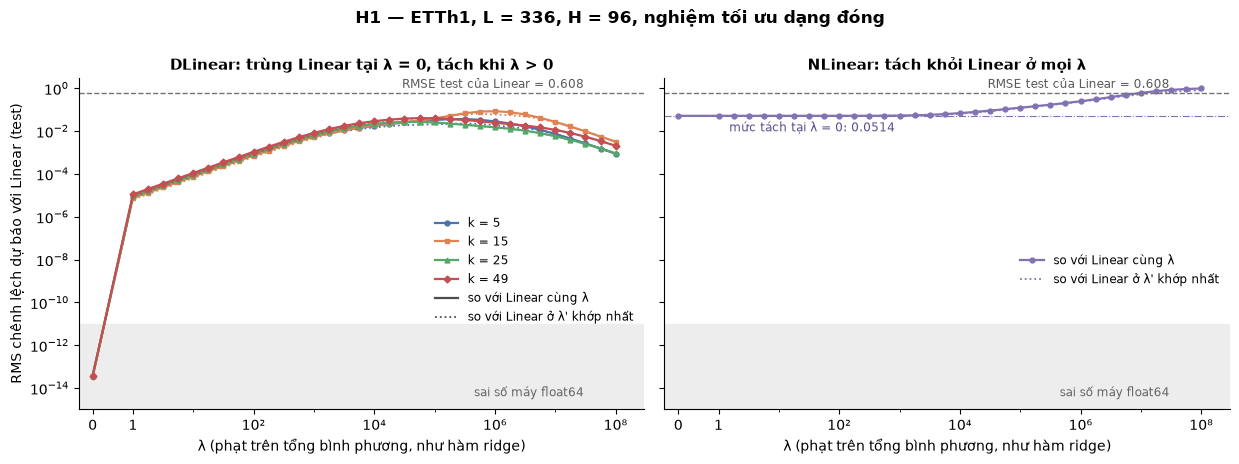

In [12]:
plt.rcParams.update({"font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold"})
PAL = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
MARK = ["o", "s", "^", "D"]
rmse_lin = np.sqrt(mse(W_lin, b_lin, X_te, Y_te))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)

def decorate(ax, title):
    ax.set_xscale("symlog", linthresh=1, linscale=0.6)
    ax.set_yscale("log")
    ax.set_xlim(-0.35, 3e8)
    ax.set_ylim(1e-15, 3)
    ax.set_xticks([0, 1, 1e2, 1e4, 1e6, 1e8])
    ax.set_xticklabels(["0", "1", "10²", "10⁴", "10⁶", "10⁸"])
    ax.axhspan(1e-15, 1e-11, color="0.93", zorder=0)
    ax.text(3e7, 3e-15, "sai số máy float64", ha="right", va="bottom", fontsize=8.5, color="0.4")
    ax.axhline(rmse_lin, ls="--", lw=1, color="0.45")
    ax.text(3e7, rmse_lin * 1.25, f"RMSE test của Linear = {rmse_lin:.3f}", ha="right", va="bottom", fontsize=8.5, color="0.35")
    ax.set_xlabel("λ (phạt trên tổng bình phương, như hàm ridge)")
    ax.set_title(title)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

ax = axes[0]
for i, k in enumerate(KERNELS):
    g = sweep[(sweep.model == "DLinear") & (sweep.k == k)]
    ax.plot(g.lam, g.rms_gap_same, color=PAL[i], marker=MARK[i], ms=3.5, lw=1.6, label=f"k = {k}")
    ax.plot(g.lam, g.rms_gap_best, color=PAL[i], ls=":", lw=1.3)
ax.plot([], [], color="0.3", lw=1.6, label="so với Linear cùng λ")
ax.plot([], [], color="0.3", ls=":", lw=1.3, label="so với Linear ở λ' khớp nhất")
ax.set_ylabel("RMS chênh lệch dự báo với Linear (test)")
ax.legend(loc="center right", fontsize=8.5, frameon=False, bbox_to_anchor=(1.0, 0.42))
decorate(ax, "DLinear: trùng Linear tại λ = 0, tách khi λ > 0")

ax = axes[1]
g = sweep[sweep.model == "NLinear"]
ax.plot(g.lam, g.rms_gap_same, color="#8172B3", marker="o", ms=3.5, lw=1.6, label="so với Linear cùng λ")
ax.plot(g.lam, g.rms_gap_best, color="#8172B3", ls=":", lw=1.3, label="so với Linear ở λ' khớp nhất")
gap0 = g[g.lam == 0].rms_gap_same.iloc[0]
ax.axhline(gap0, color="#8172B3", lw=0.8, ls="-.")
ax.text(1.5, gap0 * 0.55, f"mức tách tại λ = 0: {gap0:.4f}", fontsize=8.5, color="#5b4d8a", va="top")
ax.legend(loc="center right", fontsize=8.5, frameon=False, bbox_to_anchor=(1.0, 0.42))
decorate(ax, "NLinear: tách khỏi Linear ở mọi λ")

fig.suptitle("H1 — ETTh1, L = 336, H = 96, nghiệm tối ưu dạng đóng", fontsize=12, fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "H1_three_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()

## 9. Bảng B2

Sinh tự động từ các ô ở trên, không có số gõ tay. Lưu thêm ra `results/B2_three_predictions.md` để dán vào báo cáo.

In [13]:
from IPython.display import Markdown, display
dl = sweep[sweep.model == "DLinear"]
nlg = sweep[sweep.model == "NLinear"]
d4 = dl[dl.lam == 1e4].sort_values("k")
fmt_k = lambda col, f: "/".join(f.format(v) for v in d4[col])
n4, n8 = nlg[nlg.lam == 1e4].iloc[0], nlg[nlg.lam == 1e8].iloc[0]
# Các nhận định định tính trong bảng cũng được tính, không gõ tay
piv = dl[dl.lam > 0].pivot(index="lam", columns="k", values="rel_dW")
n_mono_k = int((np.diff(piv.values, axis=1) > 0).all(axis=1).sum())
peaks = [g.loc[g.rms_gap_same.idxmax(), "lam"] for _, g in dl[dl.lam > 0].groupby("k")]
assert np.all(np.diff(nlg.sort_values("lam").rms_gap_same.values) >= 0), "mức tách của NLinear không đơn điệu theo λ"
B2 = f"""
| | λ = 0 | λ > 0 |
|---|---|---|
| **DLinear so với Linear** | **Trùng**, cả 4 kernel. rank Z = {int(res_11.rank_Z.max())}/{2 * L}; max\\|Δŷ\\| test ≤ {res_11.max_dpred_test.max():.0e}; ‖ΔW‖/‖W‖ ≤ {res_11.rel_dW.max():.0e}; ‖∇‖ qua module ≈ {res_11.grad_ratio.max():.0e} × lúc khởi tạo | **Tách**, mức tách phụ thuộc k: ‖ΔW‖/‖W‖ tăng theo k ở {n_mono_k}/{len(piv)} giá trị λ > 0. RMS Δŷ tăng theo λ tới đỉnh ở λ ≈ {min(peaks):.2g}–{max(peaks):.2g} rồi giảm khi mọi trọng số co về 0. Tại λ = 10⁴ (k = 5/15/25/49): ‖ΔW‖/‖W‖ = {fmt_k("rel_dW", "{:.2f}")}; RMS Δŷ = {fmt_k("rms_gap_same", "{:.3f}")}; sau khi khớp λ' vẫn còn {fmt_k("rms_gap_best", "{:.3f}")} |
| **NLinear so với Linear** | **Tách.** ‖ΔW‖_F = ‖r‖·‖u‖/s = {np.linalg.norm(dW):.4f}; RMS Δŷ test = {gap0:.4f}; SSE train tăng đúng ‖r‖²/s = {r @ r / s:.1f} | **Tách**, tăng đơn điệu theo λ. RMS Δŷ = {n4.rms_gap_same:.3f} (λ = 10⁴) → {n8.rms_gap_same:.3f} (λ = 10⁸); nhỏ nhất trên toàn lưới sau khi khớp λ' là {nlg.rms_gap_best.min():.4f} |
"""
display(Markdown(B2))
with open(os.path.join(OUT_DIR, "B2_three_predictions.md"), "w", encoding="utf-8") as f:
    f.write(B2.strip() + "\n")


| | λ = 0 | λ > 0 |
|---|---|---|
| **DLinear so với Linear** | **Trùng**, cả 4 kernel. rank Z = 336/672; max\|Δŷ\| test ≤ 2e-13; ‖ΔW‖/‖W‖ ≤ 4e-13; ‖∇‖ qua module ≈ 6e-15 × lúc khởi tạo | **Tách**, mức tách phụ thuộc k: ‖ΔW‖/‖W‖ tăng theo k ở 32/33 giá trị λ > 0. RMS Δŷ tăng theo λ tới đỉnh ở λ ≈ 5.6e+04–1e+06 rồi giảm khi mọi trọng số co về 0. Tại λ = 10⁴ (k = 5/15/25/49): ‖ΔW‖/‖W‖ = 0.12/0.19/0.28/0.37; RMS Δŷ = 0.017/0.018/0.022/0.029; sau khi khớp λ' vẫn còn 0.015/0.018/0.021/0.027 |
| **NLinear so với Linear** | **Tách.** ‖ΔW‖_F = ‖r‖·‖u‖/s = 0.0694; RMS Δŷ test = 0.0514; SSE train tăng đúng ‖r‖²/s = 17002.8 | **Tách**, tăng đơn điệu theo λ. RMS Δŷ = 0.069 (λ = 10⁴) → 0.973 (λ = 10⁸); nhỏ nhất trên toàn lưới sau khi khớp λ' là 0.0514 |


## 10. Diễn giải: weight decay của DLinear phạt chỗ nào nhẹ hơn, chỗ nào nặng hơn

Nếu dồn trọng số vào một hướng `v` (chuẩn hoá), phạt của DLinear bằng `vᵀN⁻¹v` lần phạt của ridge đẳng hướng. Hai loại hướng đáng xem:

- **Lag cuối** `e_L` (giá trị gần nhất): hệ số là `[N⁻¹]_LL`. Đệm lặp làm `x_L` xuất hiện nhiều lần trong nhánh xu hướng, nên k càng lớn thì trọng số trên `x_L` càng rẻ.
- **Chu kỳ** tuần (168 giờ), ngày (24), nửa ngày (12): hệ số là trung bình của `vᵀN⁻¹v` trên cặp sin/cos. Ở phần trong chuỗi, `P` gần như bộ lọc chập với đáp ứng tần số `p(ω) = sin(kω/2) / (k·sin(ω/2))`, nên hệ số xấp xỉ `1/(1 − 2p + 2p²)`, lớn nhất bằng 2 khi `p = 1/2`, tức tại ngưỡng cắt của bộ lọc. Cột `lý thuyết` dùng công thức này để đối chiếu.

In [14]:
t_idx = np.arange(L)
rows = []
for k in KERNELS:
    row = {"k": k, "lag cuối": Ninv[k][-1, -1], "lag giữa": Ninv[k][L // 2, L // 2]}
    for T in [168, 24, 12]:
        Vb, _ = np.linalg.qr(np.stack([np.cos(2 * np.pi * t_idx / T), np.sin(2 * np.pi * t_idx / T)], 1))
        w = 2 * np.pi / T
        p = np.sin(k * w / 2) / (k * np.sin(w / 2))
        row[f"T={T}"] = np.trace(Vb.T @ Ninv[k] @ Vb) / 2
        row[f"T={T} lý thuyết"] = 1 / (1 - 2 * p + 2 * p * p)
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False, float_format="{:.3f}".format))
print()
cmp = sweep[(sweep.lam == 1e5) & (sweep.model != "NLinear")][["model", "k", "mse_val", "mse_test"]].copy()
cmp["k"] = cmp.k.map(lambda v: "" if pd.isna(v) else str(int(v)))
print("Tại λ = 10⁵ (phạt mạnh, để thấy rõ hiệu ứng):")
print(cmp.sort_values("mse_test").to_string(index=False, na_rep="", float_format="{:.4f}".format))

 k  lag cuối  lag giữa  T=168  T=168 lý thuyết  T=24  T=24 lý thuyết  T=12  T=12 lý thuyết
 5     1.212     1.139  1.003            1.003 1.143           1.143 1.606           1.609
15     0.686     1.050  1.036            1.026 1.984           1.994 0.715           0.699
25     0.477     1.030  1.097            1.075 0.956           0.923 1.077           1.083
49     0.275     1.015  1.356            1.303 1.037           1.042 1.034           1.042

Tại λ = 10⁵ (phạt mạnh, để thấy rõ hiệu ứng):
  model  k  mse_val  mse_test
DLinear 49   0.7022    0.3859
DLinear 25   0.7030    0.3871
 Linear      0.7050    0.3883
DLinear 15   0.7071    0.3886
DLinear  5   0.7092    0.3958


**Đọc kết quả.** Với k = 25 (mặc định của paper), DLinear phạt trọng số trên giá trị gần nhất chưa bằng một nửa ridge đẳng hướng; với k = 49 chỉ còn khoảng một phần tư. Ngược lại, k = 15 đặt ngưỡng cắt đúng vào chu kỳ ngày nên phạt thành phần ngày gần gấp đôi; k = 5 phạt chu kỳ nửa ngày (T = 12) khoảng 1,6 lần, và phạt lag cuối nặng hơn ridge đẳng hướng (1,21 lần). Khi phạt mạnh (λ = 10⁵), thứ tự MSE test khớp với hai cơ chế này: k = 49 và 25 tốt hơn Linear cùng λ, k = 15 xấp xỉ Linear, k = 5 kém nhất. Đây là diễn giải có số đo đi kèm, chưa phải kết luận chung; mới xem một ô (ETTh1, H = 96).

## 11. λ* chọn trên validation (xem trước cho B3 và RQ3)

λ* chọn theo MSE validation trên lưới 34 điểm (λ = 0 và 4 điểm mỗi bậc từ 1 tới 10⁸), không nhìn test. Cột `weight_decay` là giá trị PyTorch tương ứng, `2λ*/(n·H)`.

In [15]:
best = sweep.loc[sweep.groupby(["model", "k"], dropna=False).mse_val.idxmin()].copy()
best["weight_decay"] = 2 * best.lam / (n * H)
best = best[["model", "k", "lam", "weight_decay", "mse_val", "mse_test", "mae_test"]].rename(columns={"lam": "lam*"})
print(best.sort_values(["model", "k"]).to_string(index=False, na_rep="", formatters={
    "k": "{:.0f}".format, "lam*": "{:.3g}".format, "weight_decay": "{:.1e}".format,
    "mse_val": "{:.6f}".format, "mse_test": "{:.6f}".format, "mae_test": "{:.6f}".format}))

  model  k     lam* weight_decay  mse_val mse_test mae_test
DLinear  5        0      0.0e+00 0.651630 0.370235 0.391538
DLinear 15      316      1.1e-04 0.651594 0.369946 0.391401
DLinear 25      562      2.0e-04 0.651558 0.369745 0.391324
DLinear 49      562      2.0e-04 0.651553 0.369773 0.391326
 Linear           0      0.0e+00 0.651630 0.370235 0.391538
NLinear    1.78e+03      6.4e-04 0.670036 0.369424 0.391357


**Đọc kết quả.** Validation chọn λ* = 0 cho Linear, và λ* nhỏ cho DLinear và NLinear. Ở λ* đó, MSE test của cả ba mô hình nằm trong khoảng dưới 0,001. Vậy trên ô này, các khác biệt có thật ở mục 5–7 chỉ lộ ra khi phạt mạnh; ở mức phạt mà validation chọn, chúng nhỏ hơn nhiều so với khoảng cách giữa các nghiệm này và DLinear SGD (0,3766).

## Phụ lục A — `evaluate()` trong `dlinear.ipynb` lấy trung bình theo batch

`evaluate()` cộng `loss.item() / len(loader)`, tức trung bình của các MSE theo batch. Test có 2785 cửa sổ, batch 32, nên có 88 batch và **batch cuối chỉ có 1 cửa sổ**. Cửa sổ đó nhận trọng số 1/88 thay vì 1/2785. Repo LTSF-Linear không làm vậy: test loader dùng `drop_last=False` và metric tính trên mảng nối toàn bộ dự báo, tức trung bình toàn cục.

Chưa có mô hình SGD đã lưu, nên dưới đây dùng nghiệm OLS làm mô hình đại diện để đo độ lệch của cách tính này.

In [16]:
err2 = ((Y_te - pred_lin_te) ** 2).reshape(7, -1, H)       # [kênh, cửa sổ, H]
per_win = err2.mean(axis=(0, 2))                           # MSE từng cửa sổ, trên 7 kênh × 96 bước
nw = per_win.size
batch_avg = np.mean([per_win[i:i + 32].mean() for i in range(0, nw, 32)])
print(f"Số cửa sổ test: {nw}; số batch: {int(np.ceil(nw / 32))}; cỡ batch cuối: {nw - 32 * (nw // 32)}")
print(f"MSE toàn cục (cách repo tính):        {per_win.mean():.6f}")
print(f"MSE trung bình theo batch (evaluate): {batch_avg:.6f}   lệch {batch_avg - per_win.mean():+.6f}")
print(f"MSE của riêng cửa sổ cuối:            {per_win[-1]:.6f}")

Số cửa sổ test: 2785; số batch: 88; cỡ batch cuối: 1
MSE toàn cục (cách repo tính):        0.370235
MSE trung bình theo batch (evaluate): 0.371489   lệch +0.001254
MSE của riêng cửa sổ cuối:            0.484108


Với OLS, cách tính theo batch làm MSE test tăng khoảng 0,0013, tức khoảng 1/6 khoảng cách 0,0077 giữa SGD (0,3779) và OLS (0,3702). Độ lệch của mô hình SGD khác một chút: tính lại bằng trung bình toàn cục, MSE test của DLinear SGD là 0,3766 (không phải 0,3779), nên OLS tốt hơn SGD khoảng 1,7%. `src/sgd.py` đã dùng cách tính này. Sửa `evaluate()` bằng cách cộng tổng bình phương lỗi và chia cho tổng số phần tử:

```python
def evaluate(model, loader, reduction="mse"):
    model.eval(); total, count = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            d = model(x) - y
            total += (d ** 2).sum().item() if reduction == "mse" else d.abs().sum().item()
            count += d.numel()
    model.train()
    return total / count
```

## Tóm tắt

1. **1.1 đúng.** Tại λ = 0, DLinear của repo tại nghiệm tối ưu cho đúng ánh xạ của Linear OLS, sai khác ở mức sai số máy, với cả bốn kernel. Gốc đại số hiện ra trực tiếp: 672 đặc trưng của DLinear chỉ có hạng 336.
2. **1.2 đúng.** DLinear cộng weight decay đúng bằng ridge trong metric `N⁻¹` (khớp ~1e-13). Mức tách với ridge đẳng hướng phụ thuộc k (‖ΔW‖ lớn hơn khi k lớn), đạt đỉnh ở λ khoảng 10⁵–10⁶, và **không** xoá được bằng cách chỉnh lại λ. Cơ chế: phạt nhẹ trên giá trị gần nhất (hệ số 0,48 ở k = 25), phạt nặng tới 2 lần ở ngưỡng cắt của bộ lọc.
3. **1.3 đúng, và phát biểu được làm sắc hơn.** Mức tách tỉ lệ với vi phạm tổng hàng, `‖V − W_ols‖_F = ‖r‖·‖u‖/s`, và SSE train tăng đúng `‖r‖²/s`. Công thức `nlinear_constrained` đã kiểm trên ETTh1.
4. **Độ lớn thực tế.** Ở λ* chọn trên validation, ba mô hình cách nhau dưới 0,001 MSE test trên ô ETTh1 H = 96. Khác biệt cấu trúc là thật nhưng nhỏ ở mức phạt mà dữ liệu chọn.
5. **Đã sửa:** MSE test của DLinear SGD tính lại bằng trung bình toàn cục là 0,3766 (Phụ lục A).

Giới hạn: một dataset, một horizon; weight decay không phạt bias; lưới λ 4 điểm mỗi bậc.